Type day: 1, 2 or "A" for archive1
loaded 11170
loaded 11190
loaded 11200
DoF linear = 39
DoF power2 = 38
DoF fourr term = 36
DoF combintion = 36
Linear Optimised parameters filter1 =  [0.51722105]
linearco parameter errors are [0.01446049] 

Power2 Optimised parameters filter1 =  [0.56198461 0.84390738]
power 2 parameter errors [0.03182228 0.08452377] 

4param Optimised parameters filter1 =  [-0.59000309  1.13323802  0.57532651 -0.55412964]
Four term paramter errors are [0.76113273 0.6061677  0.72339264 0.5526577 ] 

New Optimised parameters filter1 =  [ 0.71200936 -0.20848273  0.15105394 -0.13651033]
New paramter errors are [0.57335375 1.23093607 0.09754307 0.71359305] 

chi^2_min filter1 = 2.7924456500236814
chi^2_min filter1 = 0.19654678878449391
chi^2_min filter1 = 0.03196611255136652
chi^2_min filter1 = 0.026670698349232157
linear reduced chi^2 filter1= 0.07160117051342772
power-2 reduced chi^2 filter1= 0.005172283915381419
4-term reduced chi^2 filter1= 0.0008879475708712922
new 

/tmp/ipykernel_33/3115736215.py:107: RuntimeWarning: invalid value encountered in true_divide
  all_x_values = list(all_x_values/(mean_counter)) #takes mean
/tmp/ipykernel_33/3115736215.py:108: RuntimeWarning: invalid value encountered in true_divide
  all_y_values = list(all_y_values/mean_counter) #takes mean


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

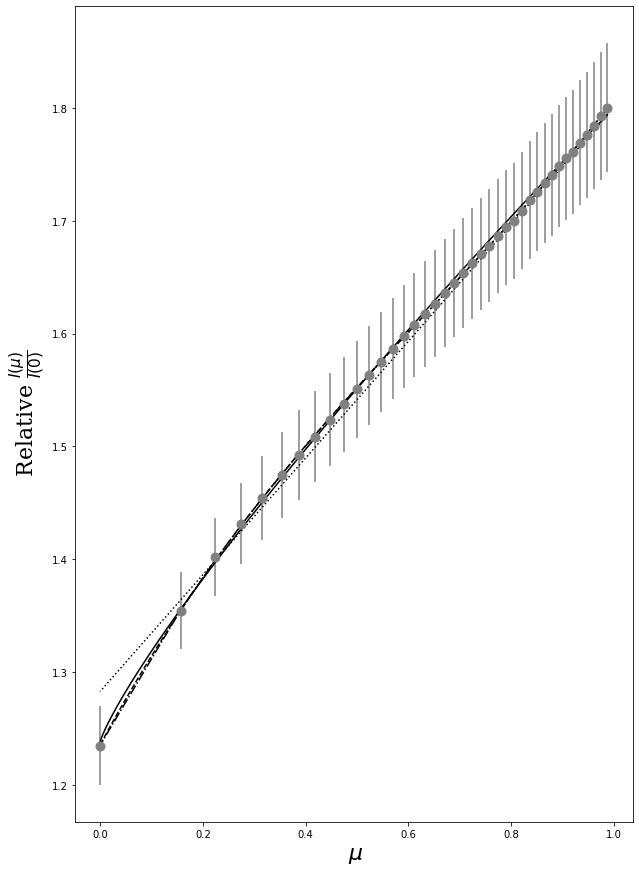

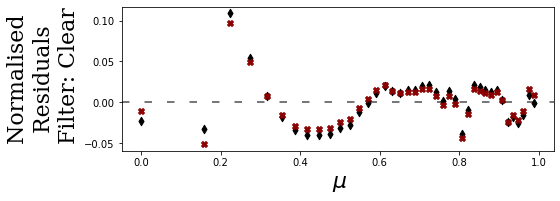

In [3]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
import matplotlib.ticker as ticker
import numpy as np
import scipy.optimize
import scipy.stats

import os
day = input('Type day: 1, 2 or "A" for archive')
numfiles=21
numfilters = 6
C0 = 64256
C0_error = 10

counter = 0
shift = 0.8

filters = ['Clear', 'U', 'B', 'V', 'R', 'I']
ff = 'serif'
fs = 22

colours = ['grey','purple','blue','green','orange','red']
markers = ['o', 'v', '2', '*', 'd', 'x']
residual_colours = ['peru','deepskyblue','black', 'darkred']
residual_marker = ['s','p','d', 'X']


def model_linear(x, u1):
    '''limd darkening'''
    return 1- u1*(1-x)

def model_power2(x, u2, u3):
    '''limd darkening'''
    return 1- u2*(1-x**u3) 

def model_four(x, u4,u5,u6,u7):
    '''limd darkening'''
    return 1- u4*(1-x**1/2)-u5*(1-x)-u6*(1-x**3/2)-u7*(1-x**2)

def model_new(x,u9, u10, u11, u12):
    '''limd darkening'''
    a = 1-x
    return u9 - u10*np.exp(-a) - u11*(np.exp(a))**2/3 - u12*(np.exp(-a))**2 

def chisq1(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_linear(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval


def chisq2(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_power2(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval

def chisq3(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_four(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval

def chisq4(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_new(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval


#extracts files
plt.figure(figsize = (10,15))

for k in range(1,numfilters+1):
    x_values=[]
    y_values=[]

    y_errors_data=[]
    radius=[]
    all_x_values = np.zeros(40)
    all_y_values = np.zeros(40)
    all_yerr_values = []
    y_errors = []
    mean_counter = 0
    for j in range(10):
        
        for i in range(numfiles):
            
            if os.path.exists(str(day)+str(k)+str(i)+str(j)): #check if file exists
                file=(str(day)+str(k)+str(i)+str(j))
                print("loaded "+str(day)+str(k)+str(i)+str(j)) #prints names of loaded files
                x_v,y_v,y_e = np.loadtxt(file, unpack=True)
                # begin binning x and y values across one data set
                all_x_values += x_v
                all_y_values += y_v
                mean_counter += 1
            
                all_yerr_values.append(y_v)
                radius.append(x_v[-1])
    
            

    all_x_values = list(all_x_values/(mean_counter)) #takes mean
    all_y_values = list(all_y_values/mean_counter) #takes mean
    R = all_x_values[-1] #finds the max binned x value and sets as the radius

    all_yerr_values = np.array(all_yerr_values)


    for i in range(len(all_y_values)):
        y_errors.append(np.std(all_yerr_values[:, i])) #finds the standard deviation of all the y values (to find error)

    # print(all_yerr_values[:, 39])
    # y_errors = list(y_errors)
    # y_errors.insert(0,C0_error) # insert error on the r = 0 value
    # y_errors = np.array(y_errors)


    all_x_values = np.array(all_x_values)
    all_y_values = np.array(all_y_values) 

    #normalising y values and propogating error
    C0 = all_y_values[0]
    

    y_errors = y_errors/C0
    C0_error = 10

    all_y_values = all_y_values/C0

    y_errors = all_y_values*np.sqrt((y_errors/all_y_values)**2 + (np.ones(len(all_y_values))*C0_error/(np.ones(len(all_y_values))*C0))**2)



    for i in range(len(all_x_values)):
            all_x_values[i]=(((R**2) - (all_x_values[i]**2))**(1/2)) /R #converts to \mu space
            
    initial1=0.8# Initial guess for fit parameters
    initial2=[0.6,0.8]
    initial3=[0.6, 10, 0.3,10]
    initial4=[-0.28738991,  0.87656608, 0.1, 0.1]

    deg_freedom1 = all_x_values.size - 1 # Make sure you understand why!
    print('DoF linear = {}'.format(deg_freedom1))

    deg_freedom2 = all_x_values.size - len(initial2) # Make sure you understand why!
    print('DoF power2 = {}'.format(deg_freedom2))

    deg_freedom3 = all_x_values.size - len(initial3) # Make sure you understand why!
    print('DoF fourr term = {}'.format(deg_freedom3))

    deg_freedom4 = all_x_values.size - len(initial4) # Make sure you understand why!
    print('DoF combintion = {}'.format(deg_freedom4))
    
    x_binsmid = all_x_values
    y_bins_mean = all_y_values
    linearco, cov1 = scipy.optimize.curve_fit(model_linear, # function to fit
                                         x_binsmid, # x data
                                         y_bins_mean, # y data
                                         sigma=y_errors, # set yerr as the array of error bars for the fit
                                         absolute_sigma=True, # errors bars DO represent 1 std error
                                         p0=initial1, # starting point for fit
                                         check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

    print('Linear Optimised parameters filter' +str(k) +' = ', linearco)
    # print('Covariance matrix = \n', cov1)
    linearco_errs = np.sqrt(np.diag(cov1))
    print('linearco parameter errors are', linearco_errs, '\n')
    
    power2co, cov2 = scipy.optimize.curve_fit(model_power2, # function to fit
                                        x_binsmid, # x data
                                         y_bins_mean, # y data
                                             sigma=y_errors, # set yerr as the array of error bars for the fit
                                         absolute_sigma=True, # errors bars DO represent 1 std error
                                         p0=initial2, # starting point for fit
                                         check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

    print('Power2 Optimised parameters filter' +str(k)+ ' = ', power2co)
    # print('Covariance matrix = \n', cov2)
    power2_errs = np.sqrt(np.diag(cov2))
    print('power 2 parameter errors',power2_errs, '\n')

    fourco, cov3 = scipy.optimize.curve_fit(model_four, # function to fit
                                       x_binsmid, # x data
                                         y_bins_mean, # y data
                                              sigma=y_errors, # set yerr as the array of error bars for the fit
                                         absolute_sigma=True, # errors bars DO represent 1 std error
                                         p0=initial3, # starting point for fit
                                         check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

    print('4param Optimised parameters filter' +str(k)+ ' = ', fourco)
#     print('Covariance matrix = \n', cov3)
    four_errs = np.sqrt(np.diag(cov3))
    print('Four term paramter errors are',four_errs, '\n')

    newco, cov4 = scipy.optimize.curve_fit(model_new, # function to fit
                                       x_binsmid, # x data
                                         y_bins_mean, # y data
                                              sigma=y_errors, # set yerr as the array of error bars for the fit
                                         absolute_sigma=True, # errors bars DO represent 1 std error
                                         p0=initial4, # starting point for fit
                                         check_finite=True)
                                          #bounds=([-0.3,0], [0, 2.])) # raise ValueError if NaN encountered (don't allow errors to pass)

    print('New Optimised parameters filter' +str(k)+ ' = ', newco)
#     print('Covariance matrix = \n', cov4)
    new_errs = np.sqrt(np.diag(cov4))
    print('New paramter errors are',new_errs, '\n')


    chisq_min1 = chisq1(linearco, x_binsmid, y_bins_mean, y_errors)
    print('chi^2_min filter' +str(k)+ ' = {}'.format(chisq_min1))

    chisq_min2 = chisq2(power2co, x_binsmid, y_bins_mean, y_errors)
    print('chi^2_min filter' +str(k)+ ' = {}'.format(chisq_min2))

    chisq_min3 = chisq3(fourco, x_binsmid, y_bins_mean, y_errors)
    print('chi^2_min filter' +str(k) +' = {}'.format(chisq_min3))


    chisq_min4 = chisq4(newco, x_binsmid, y_bins_mean, y_errors)
    print('chi^2_min filter' +str(k)+' = {}'.format(chisq_min4))

    chisq_reduced = chisq_min1/deg_freedom1
    print('linear reduced chi^2 filter' +str(k) +'= {}'.format(chisq_reduced))

    chisq_reduced = chisq_min2/deg_freedom2
    print('power-2 reduced chi^2 filter' +str(k) +'= {}'.format(chisq_reduced))

    chisq_reduced = chisq_min3/deg_freedom3
    print('4-term reduced chi^2 filter' +str(k)+'= {}'.format(chisq_reduced))
    
    chisq_reduced = chisq_min4/deg_freedom4
    print('new reduced chi^2 filter' +str(k)+'= {}'.format(chisq_reduced))
    
    
    pyplot.figure(1)
    
    pyplot.errorbar(x_binsmid, y_bins_mean +k*shift, y_errors, marker= markers[k-1], markersize = 9, linestyle='None', color = colours[k-1])

    plotting_x = np.linspace(x_binsmid[0],x_binsmid[-1], 10000)
#     ax.tick_params(labelsize = fs)


    # Generate best fit line using model function and best fit parameters, and add to plot. 
    pyplot.plot(plotting_x, 
                model_linear(plotting_x, linearco) + k*shift, color = 'black', ls = ':',
               label = 'Linear')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.)
    # Generate best fit line using model function and best fit parameters, and add to plot. 
    pyplot.plot(plotting_x, 
                model_power2(plotting_x, *power2co)+ k*shift, color ='black', ls = 'solid',
               label = 'Power-2')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.

    # Generate best fit line using model function and best fit parameters, and add to plot. 
    pyplot.plot(plotting_x, 
                model_four(plotting_x, *fourco)+ k*shift, color = 'black', ls = '--',
               label = '4-term')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.


    #Generate best fit line using model function and best fit parameters, and add to plot. 
    pyplot.plot(x_binsmid, 
               model_new(x_binsmid, *newco)+ k*shift ,  # NOTE that now we need to 'unpack' our optimised parameters with '*'.
               color = 'black', ls = '-.')
    
    plt.xlabel(' $\mu$ ',fontsize = fs, family = ff)
    plt.ylabel(' Relative $ \\frac{I(\mu)}{I(0)} $ ',fontsize = fs,family = ff)

    plt.figure(2).add_axes((1,-6+(k*shift*0.87),1,0.5))


    residuals_lin = (y_bins_mean - model_linear(x_binsmid, linearco)) / y_errors
    R_i_minus_lin = residuals_lin[:-1]
    R_i_lin = residuals_lin[1:]
    D_lin = np.sum((R_i_lin - R_i_minus_lin)**2)/np.sum(R_i_lin**2)
    
    AIC1 = chisq_min1 + 2*(1)
    AICc1 = AIC1 + (2*(1)**2 + 2*(1))/(len(x_binsmid) - 1 - 1)
    print("linear AICc Value filter "+str(k) +" = " + str(AICc1))
    print('linear Curly D linear filter' +str(k) + '=' + str(D_lin))

    residuals_power2 = (y_bins_mean - model_power2(x_binsmid, *power2co)) / y_errors
    R_i_minus_power2 = residuals_power2[:-1]
    R_i_power2 = residuals_power2[1:]
    D_power2 = np.sum((R_i_power2 - R_i_minus_lin)**2)/np.sum(R_i_power2**2)
    
    AIC2 = chisq_min2 + 2*(len(initial2))
    AICc2 = AIC2 + (2*(len(initial2))**2 + 2*(len(initial2)))/(len(x_binsmid) - len(initial2) - 1)
    print("power-2 AICc Value filter "+str(k)+" = " + str(AICc2))
    print('power-2 Curly D power-2 filter' +str(k) + '=' + str(D_power2))
    
    residuals_four = (y_bins_mean - model_four(x_binsmid, *fourco)) / y_errors
    R_i_minus_four = residuals_four[:-1]
    R_i_four = residuals_four[1:]
    D_four = np.sum((R_i_four - R_i_minus_four)**2)/np.sum(R_i_four**2)
    AIC3 = chisq_min3 + 2*(len(initial3))
    AICc3 = AIC3 + (2*(len(initial3))**2 + 2*(len(initial3)))/(len(x_binsmid) - len(initial3) - 1)
    print("4-term AICc Value filter "+str(k) +" = " + str(AICc3))
    print('4-term Curly D 4-term filter' +str(k) + '=' + str(D_four))
    
    residuals_new = (y_bins_mean - model_new(x_binsmid, *newco)) / y_errors
    R_i_minus_new = residuals_new[:-1]
    R_i_new = residuals_new[1:]
    D_new = np.sum((R_i_new - R_i_minus_new)**2)/np.sum(R_i_new**2)
    AIC4 = chisq_min4 + 2*(len(initial4))
    AICc4 = AIC4 + (2*(len(initial4))**2 + 2*(len(initial4)))/(len(x_binsmid) - len(initial4) - 1)
    print("NEW AICc Value filter "+str(k) +" = " + str(AICc4))
    print('NEW Curly D new filter' +str(k)+ '=' + str(D_new))



    plt.figure(2)
#     plt.scatter(x_binsmid, residuals_lin, color = residual_colours[0], marker = residual_marker[0])
#     plt.scatter(x_binsmid, residuals_power2, color = residual_colours[1], marker = residual_marker[1] )
    plt.scatter(x_binsmid, residuals_four, color = residual_colours[2], marker = residual_marker[2])
    plt.scatter(x_binsmid, residuals_new, color = residual_colours[3], marker = residual_marker[3])
    plt.axhline(y=0, color= 'black', linestyle= (0, (5,10)), alpha = 0.7)
    plt.xlabel(' $\mu$ ',fontsize = fs, family = ff)
    plt.ylabel(' Normalised \n Residuals \n Filter: ' + str(filters[k-1]),fontsize = fs,family = ff)
    

    
    counter +=1 







    x_values=[]
    y_values=[]

    y_errors_data=[]
    radius=[]
    all_x_values = np.zeros(40)
    all_y_values = np.zeros(40)
    all_yerr_values = []
    
    C0_error = 10
    y_errors = []
#     plt.figure(1).savefig('FINAL_GTETA', dpi=250, bbox_inches='tight', pad_inches=0.3)
#     plt.figure(2).savefig('FINAL_Residuals2Models', dpi=400, bbox_inches='tight', pad_inches=0.3)

pyplot.show()



## 

In [4]:
def model_linear(x, u1):
    '''limd darkening'''
    return 1- u1*(1-x)

def model_power2(x, u2, u3):
    '''limd darkening'''
    return 1- u2*(1-x**u3)

def model_four(x, u4,u5,u6,u7):
    '''limd darkening'''
    return 1- u4*(1-x**1/2)-u5*(1-x)-u6*(1-x**3/2)-u7*(1-x**2)

    
def model_combo(x,u8,u9,u10,u11,u12,u13):
    '''limd darkening'''
    return 1- u8*(1-x)-u9*(1-x**1/2)-u10*(1-x**3/2)-u11*(1-x**2)-u12*(1-x**u13)

In [5]:
initial1=0.8# Initial guess for fit parameters
initial2=[0.6,0.8]
initial3=[0.6, 10, 0.3,10]
initial4=[0.6, 0.2, 0.0, 1.0,1,1]

deg_freedom1 = all_x_values.size - 1 # Make sure you understand why!
print('DoF linear = {}'.format(deg_freedom1))

deg_freedom2 = all_x_values.size - len(initial2) # Make sure you understand why!
print('DoF power2 = {}'.format(deg_freedom2))

deg_freedom3 = all_x_values.size - len(initial3) # Make sure you understand why!
print('DoF fourr term = {}'.format(deg_freedom3))

deg_freedom4 = all_x_values.size - len(initial4) # Make sure you understand why!
print('DoF combintion = {}'.format(deg_freedom4))

DoF linear = 39
DoF power2 = 38
DoF fourr term = 36
DoF combintion = 34


In [6]:
x_binsmid = all_x_values
y_bins_mean = all_y_values
linearco, cov1 = scipy.optimize.curve_fit(model_linear, # function to fit
                                     x_binsmid, # x data
                                     y_bins_mean, # y data
                                     sigma=y_errors, # set yerr as the array of error bars for the fit
                                     absolute_sigma=True, # errors bars DO represent 1 std error
                                     p0=initial1, # starting point for fit
                                     check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

print('Linear Optimised parameters = ', linearco, '\n')
# print('Covariance matrix = \n', cov1)

power2co, cov2 = scipy.optimize.curve_fit(model_power2, # function to fit
                                    x_binsmid, # x data
                                     y_bins_mean, # y data
                                         sigma=y_errors, # set yerr as the array of error bars for the fit
                                     absolute_sigma=True, # errors bars DO represent 1 std error
                                     p0=initial2, # starting point for fit
                                     check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

print('Power2 Optimised parameters = ', power2co, '\n')
# print('Covariance matrix = \n', cov2)

fourco, cov3 = scipy.optimize.curve_fit(model_four, # function to fit
                                   x_binsmid, # x data
                                     y_bins_mean, # y data
                                          sigma=y_errors, # set yerr as the array of error bars for the fit
                                     absolute_sigma=True, # errors bars DO represent 1 std error
                                     p0=initial3, # starting point for fit
                                     check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

print('4param Optimised parameters = ', fourco, '\n')
print('Covariance matrix = \n', cov3)

# comboco, cov4 = scipy.optimize.curve_fit(model_combo, # function to fit
#                                    x_binsmid, # x data
#                                      y_bins_mean, # y data
#                                          sigma=y_errors,# set yerr as the array of error bars for the fit
#                                      absolute_sigma=True, # errors bars DO represent 1 std error
#                                      p0=initial4, # starting point for fit
#                                      check_finite=True) # raise ValueError if NaN encountered (don't allow errors to pass)

# print('Optimised parameters = ', comboco, '\n')
# print('Covariance matrix = \n', cov4)

def chisq1(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_linear(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval


def chisq2(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_power2(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval

def chisq3(model_params, x_binsmid, y_bins_mean, y_error):
    chisqval=0
    for i in range(len(x_binsmid)):
        chisqval += ((y_bins_mean[i] - model_four(x_binsmid[i], *model_params))/y_error[i])**2 
        # NOTE again the asterisk (*) before 'model_params' here!
    return chisqval

# def chisq4(model_params, x_binsmid, y_bins_mean, y_error):
#     chisqval=0
#     for i in range(len(x_binsmid)):
#         chisqval += ((y_bins_mean[i] - model_combo(x_binsmid[i], *model_params))/y_error[i])**2 
#         # NOTE again the asterisk (*) before 'model_params' here!
#     return chisqval

chisq_min1 = chisq1(linearco, x_binsmid, y_bins_mean, y_errors)
print('chi^2_min = {}'.format(chisq_min1))

chisq_min2 = chisq2(power2co, x_binsmid, y_bins_mean, y_errors)
print('chi^2_min = {}'.format(chisq_min2))

chisq_min3 = chisq3(fourco, x_binsmid, y_bins_mean, y_errors)
print('chi^2_min = {}'.format(chisq_min3))

# chisq_min4 = chisq4(comboco, x_binsmid, y_bins_mean, y_errors)
# print('chi^2_min = {}'.format(chisq_min4))

chisq_reduced = chisq_min1/deg_freedom1
print('linear reduced chi^2 = {}'.format(chisq_reduced))

chisq_reduced = chisq_min2/deg_freedom2
print('power-2 reduced chi^2 = {}'.format(chisq_reduced))

chisq_reduced = chisq_min3/deg_freedom3
print('4-term reduced chi^2 = {}'.format(chisq_reduced))

Linear Optimised parameters =  [0.51277363] 

Power2 Optimised parameters =  [1.46509143 0.30932496] 

4param Optimised parameters =  [ 0.70979009 -0.11786839 -0.7285384   0.6774829 ] 

Covariance matrix = 
 [[ 0.00816375 -0.01049128 -0.00813831  0.0090412 ]
 [-0.01049128  0.01372455  0.0104617  -0.01176761]
 [-0.00813831  0.0104617   0.00811308 -0.00901519]
 [ 0.0090412  -0.01176761 -0.00901519  0.01010559]]
chi^2_min = 7585.229675405922
chi^2_min = 5193.500066441744
chi^2_min = 338.2476735603382
linear reduced chi^2 = 194.49306860015184
power-2 reduced chi^2 = 136.6710543800459
4-term reduced chi^2 = 9.395768710009396


/tmp/ipykernel_185/2425642624.py:7: RuntimeWarning: divide by zero encountered in power
  return 1- u2*(1-x**u3)


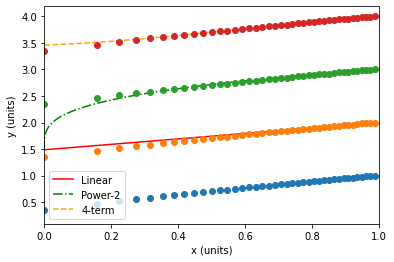

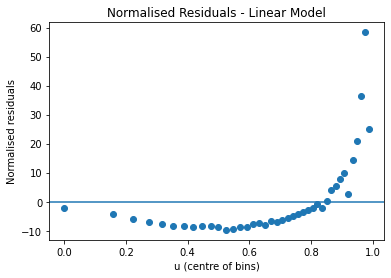

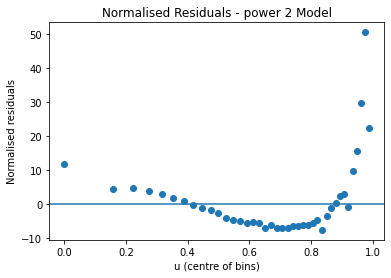

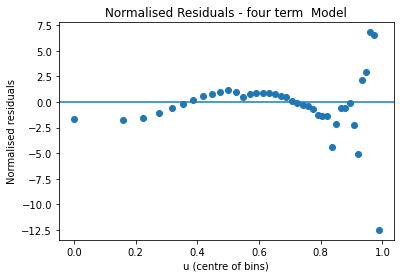

In [25]:
pyplot.figure()
pyplot.errorbar(x_binsmid, y_bins_mean, y_errors, marker='o', linestyle='None')
pyplot.xlabel('x (units)')
pyplot.ylabel('y (units)')

plotting_x = np.linspace(x_binsmid[0],x_binsmid[-1], 10000)


# Generate best fit line using model function and best fit parameters, and add to plot. 
pyplot.plot(plotting_x, 
            model_linear(plotting_x, linearco), color = 'red', ls = 'solid',
           label = 'Linear')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.)
# Generate best fit line using model function and best fit parameters, and add to plot. 
pyplot.plot(plotting_x, 
            model_power2(plotting_x, *power2co), color ='g', ls = '-.',
           label = 'Power-2')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.

# Generate best fit line using model function and best fit parameters, and add to plot. 
pyplot.plot(plotting_x, 
            model_four(plotting_x, *fourco), color = 'orange', ls = '--',
           label = '4-term')  # NOTE that now we need to 'unpack' our optimised parameters with '*'.
            

# #Generate best fit line using model function and best fit parameters, and add to plot. 
# pyplot.plot(x_binsmid, 
#            model_combo(x_binsmid, *comboco),  # NOTE that now we need to 'unpack' our optimised parameters with '*'.
#            'k', label='optimised')

pyplot.legend()
pyplot.show()

# calculate normalised residuals linear model
norm_residuals = (y_bins_mean - model_linear(x_binsmid, linearco)) / y_errors

# plot
pyplot.figure()
pyplot.errorbar(x_binsmid, norm_residuals, marker='o', linestyle='None')

# zero reference line
pyplot.axhline(0)

pyplot.xlabel('u (centre of bins)')
pyplot.ylabel('Normalised residuals')
pyplot.title('Normalised Residuals - Linear Model')

pyplot.show()

# calculate normalised residuals power 2 model
norm_residuals = (y_bins_mean - model_power2(x_binsmid, *power2co)) / y_errors

# plot
pyplot.figure()
pyplot.errorbar(x_binsmid, norm_residuals, marker='o', linestyle='None')

# zero reference line
pyplot.axhline(0)

pyplot.xlabel('u (centre of bins)')
pyplot.ylabel('Normalised residuals')
pyplot.title('Normalised Residuals - power 2 Model')

pyplot.show()

# calculate normalised residuals four term model
norm_residuals = (y_bins_mean - model_four(x_binsmid, *fourco)) / y_errors

# plot
pyplot.figure()
pyplot.errorbar(x_binsmid, norm_residuals, marker='o', linestyle='None')

# zero reference line
pyplot.axhline(0)

pyplot.xlabel('u (centre of bins)')
pyplot.ylabel('Normalised residuals')
pyplot.title('Normalised Residuals - four term  Model')

pyplot.show()

# # calculate normalised residuals combo model
# norm_residuals = (y_bins_mean - model_combo(x_binsmid, *comboco)) / y_errors

# # plot
# pyplot.figure()
# pyplot.errorbar(x_binsmid, norm_residuals, marker='o', linestyle='None')

# # zero reference line
# pyplot.axhline(0)

# pyplot.xlabel('u (centre of bins)')
# pyplot.ylabel('Normalised residuals')
# pyplot.title('Normalised Residuals - Combined Model')

# pyplot.show()



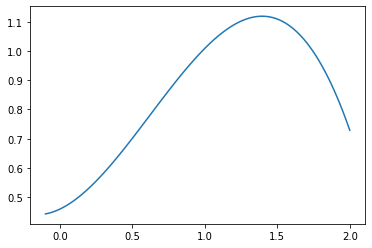

In [8]:
plt.plot(np.linspace(-0.1,2,100), model_four(np.linspace(-0.1,2,100), *fourco))

In [134]:
def residual_model(x, a, b, c):
    return 

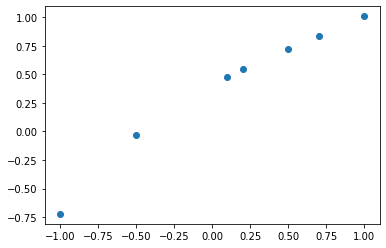

In [105]:
plt.scatter(np.array([-1,-0.5,0.1,0.2,0.5,0.7,1]) , model_four(np.array([-1,-0.5,0.1,0.2,0.5,0.7,1]), *fourco))

In [97]:
arr = [1,3,4,5]

arr.insert(1,2)

print(arr)

[1, 2, 3, 4, 5]
